# Titelgenerator voor HBO Kennisbank

Deze notebook fine-tunet een klein seq2seq-model op hbo_kennisbank_clean.csv om van een abstract een compacte, informatieve titel te genereren.

De opzet is bewust licht gehouden zodat de training past binnen ongeveer 12 GB RAM en binnen een redelijke looptijd.

## 1. Importen en Configuratie

In deze stap laden we alle benodigde libraries en stellen we de belangrijkste configuraties en hyperparameters in voor het project.

Deze instellingen bepalen:
- welk model gebruikt wordt
- hoeveel data wordt gebruikt
- hoe lang teksten mogen zijn
- hoe de training verloopt

---

### Waarom FLAN-T5-small?

Er is gekozen voor `google/flan-t5-small` omdat dit model compact en efficiënt is. Het model is speciaal geschikt voor instructie-gebaseerde teksttaken zoals:
- samenvatting
- tekstgeneratie
- titelgeneratie

Daarnaast kan het model binnen de hardwarelimieten van de opdracht worden getraind.

---

### Belangrijkste instellingen

De belangrijkste configuraties zijn:

- **max_source_length = 256**
  - maximale lengte van het abstract als input

- **max_target_length = 32**
  - maximale lengte van de gegenereerde titel

- **max_train_examples = 400**
  - beperkt de trainingsdata zodat training binnen de beschikbare RAM blijft

- **random_state = 42**
  - zorgt voor reproduceerbare resultaten

---

### Waarom een prefix gebruiken?

Voor iedere input voegen we een instructie toe:

```python
"Genereer een korte en informatieve titel:"
```

Dit is een vorm van instruction prompting. Hierdoor begrijpt het model beter welke taak uitgevoerd moet worden.

---

### Reproduceerbaarheid

Met `set_seed()` zorgen we ervoor dat:

trainingsresultaten consistenter blijven
experimenten beter vergelijkbaar zijn
evaluaties reproduceerbaar worden

In [21]:
#Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)
import evaluate
from IPython.display import display
from groq import Groq
import re
import time

In [2]:
# Paden en hyperparameters
csv_path = Path(r"hbo_kennisbank_clean.csv")
model_name = "google/flan-t5-small"
output_dir = Path("title_generator_flan_t5_small")
random_state = 42
max_source_length = 256
max_target_length = 32
max_train_examples = 400
max_val_examples = 100

prefix = "Genereer een korte en informatieve titel: "

set_seed(random_state)
output_dir.mkdir(exist_ok=True)


## 2. Data Laden en Inspecteren

In deze stap laden we de gescrapete HBO Kennisbank dataset in en controleren we de kwaliteit van de data.

Het doel hiervan is om:
- foutieve rijen te verwijderen
- lege waardes op te schonen
- een consistente dataset te maken voor training

---

### Waarom data cleaning belangrijk is

Language models zijn gevoelig voor slechte trainingsdata. Wanneer:
- abstracten leeg zijn
- titels ontbreken
- duplicaten aanwezig zijn

kan het model verkeerde patronen leren.

Daarom wordt de dataset eerst opgeschoond voordat het fine-tuningproces begint.

---

### Uitgevoerde cleaning stappen

De volgende stappen worden toegepast:

- verwijderen van lege waardes (`dropna`)
- verwijderen van dubbele rijen
- verwijderen van lege strings
- resetten van de index

Hierdoor blijft alleen bruikbare trainingsdata over.

---

### Verwachte kolommen

Voor deze taak gebruiken we twee belangrijke kolommen:

- **abstract**
  - invoertekst voor het model

- **title**
  - doeloutput die het model moet leren genereren

Dit maakt de dataset geschikt voor een seq2seq titelgeneratie taak.

---

### Dataset inspecteren

Na het laden tonen we:
- het aantal bruikbare rijen
- enkele voorbeeldrecords

Hiermee controleren we of:
- de scraping correct verlopen is
- de data logisch opgebouwd is
- de abstracten voldoende tekst bevatten

In [3]:
# 2. Data laden en inspecteren
df = pd.read_csv(csv_path)
expected_columns = {"title", "abstract"}
missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Ontbrekende kolommen in CSV: {sorted(missing_columns)}")

df = df.loc[:, ["abstract", "title"]].dropna().copy()
df["abstract"] = df["abstract"].astype(str).str.strip()
df["title"] = df["title"].astype(str).str.strip()
df = df[(df["abstract"] != "") & (df["title"] != "")]
df = df.drop_duplicates(subset=["abstract", "title"]).reset_index(drop=True)

print(f"Aantal bruikbare rijen: {len(df)}")

display(df.head())


Aantal bruikbare rijen: 549


,abstract,title
0,Achtergrond: Het herstel na conservatief behan...,Fysiotherapeutische analyse en conservatieve b...
1,In deze scriptie zijn 144 metalen militaria ui...,Civiel centrum Oppidum Batavorum
2,The escalating plastic waste crisis has increa...,Comparative analysis of fingermark development...
3,Artikel over de rol van passie in de amateurkunst,Passie in de amateurkunst
4,Dit rapport is deel I van twee delen waarin de...,A legal overview on International & European S...


## 3. Voorbewerking, Split en Tokenisatie

In deze stap bereiden we de dataset voor op training.

Language models kunnen namelijk niet direct met ruwe tekst werken. Daarom moeten teksten eerst:
- opgesplitst worden
- getokenized worden
- omgezet worden naar numerieke representaties

---

### Train- en validatiesplit

De dataset wordt opgesplitst in:
- **80% training**
- **20% validatie**

De trainingsset wordt gebruikt om het model te trainen, terwijl de validatieset wordt gebruikt om de prestaties van het model te evalueren op ongeziene data.

---

### Waarom Hugging Face Datasets?

De pandas DataFrames worden omgezet naar Hugging Face `Dataset` objecten.

Dit biedt voordelen zoals:
- efficiëntere preprocessing
- betere integratie met transformers
- snellere batching tijdens training

---

### Waarom tokenisatie?

Language models werken niet direct met woorden, maar met tokens.

Tokenisatie:
- splitst tekst op in kleinere onderdelen
- zet tekst om naar token-ID’s
- maakt input geschikt voor neurale netwerken

---

### Preprocessing van de input

Voor iedere abstract voegen we eerst een instructie toe:

```python
"Genereer een korte en informatieve titel:"
```
Daarna:

- wordt de tekst getokenized
- worden lange teksten afgekapt (`truncation`)
- worden labels voorbereid voor training

---

### Output van preprocessing

Na preprocessing bevat iedere trainingsrij:

- input_ids
- attention_mask
- labels

Deze worden gebruikt tijdens het fine-tuningproces van het model.


In [4]:
# 3. Voorbewerking, split en tokenisatie
train_df, val_df = train_test_split(df, test_size=0.2, random_state=random_state)
train_df = train_df.head(max_train_examples).reset_index(drop=True)
val_df = val_df.head(max_val_examples).reset_index(drop=True)

dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df, preserve_index=False),
        "validation": Dataset.from_pandas(val_df, preserve_index=False),
    }
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_batch(batch):
    inputs = [prefix + text for text in batch["abstract"]]
    model_inputs = tokenizer(inputs, max_length=max_source_length, truncation=True)
    labels = tokenizer(text_target=batch["title"], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

tokenized = dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

display(train_df.head(3))

display(val_df.head(3))


Map: 100%|██████████| 100/100 [00:00<00:00, 1890.38 examples/s]


,abstract,title
0,Dysfagie is een symptoom dat wordt gekenmerkt ...,De TotalCup® in de zorgpraktijk: een kwalitati...
1,In deze lijst staan alle interventie-ideeën be...,Lijst met interventie-ideeën van mbo-studenten
2,Met toestemming vqn de uitgever overgenomen ui...,Soenveld_dewit_19122025_essayrobotrechten_nede...


,abstract,title
0,Het objectief meten van spierkracht is essenti...,De intra-rater betrouwbaarheid van de citecmot...
1,Qualitative research in the form of interviews...,Improving the feedback systems at Van der Lind...
2,El vidrio aislante viejo suele acabar en aplic...,Vidrio Plano 100% Reutilizado: Dando una Segun...


## 4. Model Fine-tunen en Evalueren

In deze stap wordt het gekozen language model verder getraind op onze HBO Kennisbank dataset. Het doel is om het model te leren hoe het op basis van een abstract een korte, informatieve en academische titel kan genereren.

---

### Waarom FLAN-T5-small?

Er is gekozen voor `google/flan-t5-small` omdat dit een compact seq2seq-model is dat goed geschikt is voor tekstgeneratie taken zoals samenvatting en titelgeneratie. Daarnaast is het model licht genoeg om binnen de hardwarelimieten van de opdracht te trainen (~12GB RAM).

---

### Waarom seq2seq?

Titelgeneratie is een sequence-to-sequence taak:
- de input is een abstract
- de output is een gegenereerde titel

Het model leert hierbij om langere tekst om te zetten naar een compacte samenvattende titel.

---

### Fine-tuning instellingen

De belangrijkste hyperparameters zijn:

- **Learning rate = 3e-4**
  - relatief laag om stabiel verder te trainen op een bestaand model

- **Batch size = 4**
  - klein gehouden vanwege beperkte GPU/RAM capaciteit

- **Epochs = 2**
  - voorkomt overfitting op de relatief kleine dataset

- **Beam search = 4**
  - gebruikt tijdens generatie voor betere kwaliteit en coherentie

---

### Evaluatiemethode

Voor de evaluatie gebruiken we:
- **ROUGE scores**
- **AI feedback via RLAIF**

ROUGE meet hoeveel overlap er is tussen de gegenereerde titel en de echte titel. Omdat ROUGE vooral woordoverlap meet, wordt aanvullend AI feedback gebruikt om ook kwaliteit, stijl en relevantie te beoordelen.

In [5]:
# 4. Model fine-tunen en evalueren
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
rouge = evaluate.load("rouge")


def compute_metrics(eval_preds):
    import numpy as np

    predictions, labels = eval_preds
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Convert tensors to numpy
    try:
        if hasattr(predictions, "cpu"):
            predictions = predictions.cpu().numpy()
    except Exception:
        pass
    try:
        if hasattr(labels, "cpu"):
            labels = labels.cpu().numpy()
    except Exception:
        pass

    # Replace negative values (including -100) with pad token id for safe decoding
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    if predictions is not None:
        predictions = np.where(predictions < 0, pad_id, predictions)
    if labels is not None:
        labels = np.where(labels < 0, pad_id, labels)

    # Ensure integer dtype for tokenizer
    predictions = predictions.astype(np.int64)
    if labels is not None:
        labels = labels.astype(np.int64)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = (
        tokenizer.batch_decode(labels, skip_special_tokens=True) if labels is not None else [""] * len(decoded_preds)
    )

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [lab.strip() for lab in decoded_labels]

    scores = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {metric: round(value, 4) for metric, value in scores.items()}


training_args = Seq2SeqTrainingArguments(
    output_dir=str(output_dir),
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1272.85it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


# Training


In [6]:
# Veiligheids-flag om training expliciet te starten
run_training = True

# Training
if run_training:
    trainer.train()
    eval_results = trainer.evaluate()
    print(eval_results)
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
else:
    print("Training is uitgeschakeld. Zet `run_training = True` in de configuratiecel om te starten.")


c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,6.847442,3.248805,0.200300,0.076000,0.168600,0.170400
2,5.966657,3.271343,0.207300,0.089200,0.179600,0.180900


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]
c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].
c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
5.966657,3.271343,2,0.207300,0.089200,0.179600,0.180900


{'eval_loss': 3.2713425159454346, 'eval_rouge1': 0.2073, 'eval_rouge2': 0.0892, 'eval_rougeL': 0.1796, 'eval_rougeLsum': 0.1809}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]


## 5. Titelgeneratie, Samplingstrategieën en Evaluatie

Na het fine-tunen testen we verschillende generatie-strategieën. Iedere strategie beïnvloedt hoe het model nieuwe titels genereert.

### Greedy Decoding

Bij greedy decoding kiest het model telkens het meest waarschijnlijke volgende token.

Voordelen:
- snel
- stabiel
- voorspelbare output

Nadelen:
- vaak korte of minder creatieve titels

---

### Beam Search

Beam search houdt meerdere mogelijke zinnen tegelijk bij en kiest uiteindelijk de beste kandidaat.

Voordelen:
- hogere kwaliteit
- betere grammatica
- meer complete academische titels

Nadelen:
- langzamer
- minder creatief

---

### Top-p Sampling

Top-p sampling introduceert gecontroleerde willekeur in de generatie.

Voordelen:
- creatievere output
- meer variatie

Nadelen:
- soms minder consistent
- grotere kans op irrelevante woorden

---

### Waarom meerdere strategieën vergelijken?

De gekozen samplingstrategie heeft grote invloed op:
- kwaliteit
- creativiteit
- consistentie

Daarom vergelijken we meerdere strategieën met:
- ROUGE scores
- AI evaluatie via RLAIF

In [7]:
# 5. Generatie, sampling en evaluatie
model = trainer.model
model.eval()
device = model.device

def generate_title(abstract, **generation_kwargs):
    prompt = prefix + abstract
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length).to(device)
    generated = model.generate(
        **inputs,
        #max_new_tokens=max_target_length,
        **generation_kwargs,
    )

    return tokenizer.decode(generated[0], skip_special_tokens=True).strip()



generation_strategies = {
    "greedy": {"do_sample": False, "num_beams": 1},
    "beam_4": {"do_sample": False, "num_beams": 4},
    "top_p": {"do_sample": True, "top_p": 0.9, "temperature": 0.8, "num_beams": 1},
}

sample_rows = val_df.head(5).copy()

for strategy_name, kwargs in generation_strategies.items():
    print(f"\n=== {strategy_name} ===")
    for _, row in sample_rows.iterrows():
        prediction = generate_title(row["abstract"], **kwargs)
        print("REF :", row["title"])
        print("PRED:", prediction)
        print("---")



def evaluate_strategy(strategy_kwargs, sample_size=25):
    subset = val_df.head(sample_size)
    predictions = [generate_title(abstract, **strategy_kwargs) for abstract in subset["abstract"]]
    references = subset["title"].tolist()

    return rouge.compute(predictions=predictions, references=references, use_stemmer=True)



strategy_scores = {
    name: evaluate_strategy(kwargs, sample_size=25)
    for name, kwargs in generation_strategies.items()
}

strategy_scores



=== greedy ===
REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: CitecMotion Hand Held Dynamometer
---
REF : Improving the feedback systems at Van der Linde Catering.
PRED: Interviews in Van der Linde Catering
---
REF : Vidrio Plano 100% Reutilizado: Dando una Segunda Vida a Cada Panel de Vidrio
PRED: Aislante en el vidrio aislante
---
REF : Ondergrondse energieopslag in Twente Governance arrangementen
PRED: Ondergrondse opslag
---
REF : Wat leren leerlingen en studenten over democratie? Een analyse van lesmethoden maatschappijleer en mbo-burgerschap
PRED: De democratische erosie het versterken van een
---

=== beam_4 ===
REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: CitecMotion Hand Held Dynamometer
---
REF : Improving the feedback systems at Van der Linde Cater

{'greedy': {'rouge1': np.float64(0.3038980403109436),
  'rouge2': np.float64(0.13334499971564595),
  'rougeL': np.float64(0.25780587751555495),
  'rougeLsum': np.float64(0.2577504569504569)},
 'beam_4': {'rouge1': np.float64(0.3349294640716167),
  'rouge2': np.float64(0.1803934165673296),
  'rougeL': np.float64(0.30364964000070527),
  'rougeLsum': np.float64(0.30134807055784724)},
 'top_p': {'rouge1': np.float64(0.20119201957462826),
  'rouge2': np.float64(0.09327812284334022),
  'rougeL': np.float64(0.18053020006421538),
  'rougeLsum': np.float64(0.17819397703745532)}}

Beam search genereerde gemiddeld de meest volledige en academische titels. Top-p sampling produceerde creatievere outputs, maar was minder consistent. Greedy decoding was het meest stabiel, maar leverde soms te korte titels op.

## 6. RLAIF (Reinforcement Learning from AI Feedback)

In deze stap passen we Reinforcement Learning from AI Feedback (RLAIF) toe.

In plaats van menselijke beoordelaars gebruiken we een tweede language model als evaluator. Dit evaluator-model beoordeelt de gegenereerde titels op:

- relevantie
- duidelijkheid
- academische stijl

---

### Waarom RLAIF?

ROUGE scores meten vooral overlap tussen woorden, maar zeggen minder over:
- leesbaarheid
- stijl
- inhoudelijke kwaliteit

Daarom gebruiken we aanvullend AI feedback om de gegenereerde titels kwalitatief te beoordelen.

---

### Werkwijze

Voor iedere generatie-strategie:
1. genereert het fine-tuned model een titel
2. beoordeelt het evaluator-model de titel met een score van 0-10
3. worden de scores opgeslagen in een CSV-bestand

Hiermee kunnen de verschillende generatie-strategieën objectiever met elkaar worden vergeleken.

De AI feedback werd gebruikt om de verschillende generatie-strategieën te vergelijken. Op basis van de gemiddelde AI scores werd beam search geselecteerd als beste strategie voor verdere generatie.

ROUGE meet voornamelijk overlap tussen woorden en referentietitels. Hierdoor worden creatieve of alternatieve correcte titels soms lager beoordeeld. Daarom is aanvullend gebruikgemaakt van AI feedback via RLAIF.

In [8]:
#client aanmaken
with open("api_key.txt", "r") as f:
    API_KEY = f.read().strip()

client = Groq(api_key=API_KEY)

In [9]:
# Functie voor AI feedback
def score_title_with_ai(abstract, title):

    prompt = f"""
    Score deze academische titel van 0-10.

    Criteria:
    - relevantie
    - duidelijkheid
    - academische stijl

    Geef alleen een getal.

    Abstract:
    {abstract}

    Titel:
    {title}
    """

    #versturen van prompt naar evaluator-model
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )
    #output van model ophalen
    text = response.choices[0].message.content

    print(text)
    
    #numerieke score uit tekst halen
    match = re.search(r"\d+(\.\d+)?", text)

    if match:
        return float(match.group())

    return None


In [10]:
#kleine subset selecteren
subset = val_df.head(5)

rlaif_rows = []

In [11]:
#RLAIF evaluatie uitvoeren
for _, row in subset.iterrows():

    abstract = row["abstract"]
    real_title = row["title"]

    #verschillende generation strategieën testen
    for strategy_name, kwargs in generation_strategies.items():

        # Titel genereren
        candidate_title = generate_title(
            abstract,
            **kwargs
        )

        print("\n===================================")
        print("STRATEGY:", strategy_name)
        print("REAL TITLE:", real_title)
        print("GENERATED TITLE:", candidate_title)

        # AI score ophalen
        try:

            score = score_title_with_ai(
                abstract,
                candidate_title
            )

        except Exception as e:

            print("ERROR:", e)

            score = None

        print("AI SCORE:", score)

        # Resultaten Opslaan
        rlaif_rows.append({
            "abstract": abstract,
            "real_title": real_title,
            "candidate_title": candidate_title,
            "strategy": strategy_name,
            "score": score
        })

        # Kleine delay tegen rate limits
        time.sleep(2)


STRATEGY: greedy
REAL TITLE: De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
GENERATED TITLE: CitecMotion Hand Held Dynamometer
5
AI SCORE: 5.0

STRATEGY: beam_4
REAL TITLE: De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
GENERATED TITLE: CitecMotion Hand Held Dynamometer
6
AI SCORE: 6.0

STRATEGY: top_p
REAL TITLE: De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
GENERATED TITLE: CitecMotion Hand Held Dynamometer
8
AI SCORE: 8.0

STRATEGY: greedy
REAL TITLE: Improving the feedback systems at Van der Linde Catering.
GENERATED TITLE: Interviews in Van der Linde Catering
6
AI SCORE: 6.0

STRATEGY: beam_4
REAL TITLE: Improving the feedback systems at Van der Linde Catering.
GENERATED TITLE: 

In [12]:
rlaif_df = pd.DataFrame(rlaif_rows)

In [13]:
print("\nRLAIF RESULTATEN:")

display(rlaif_df)


RLAIF RESULTATEN:


,abstract,real_title,candidate_title,strategy,score
0,Het objectief meten van spierkracht is essenti...,De intra-rater betrouwbaarheid van de citecmot...,CitecMotion Hand Held Dynamometer,greedy,5.0
1,Het objectief meten van spierkracht is essenti...,De intra-rater betrouwbaarheid van de citecmot...,CitecMotion Hand Held Dynamometer,beam_4,6.0
2,Het objectief meten van spierkracht is essenti...,De intra-rater betrouwbaarheid van de citecmot...,CitecMotion Hand Held Dynamometer,top_p,8.0
3,Qualitative research in the form of interviews...,Improving the feedback systems at Van der Lind...,Interviews in Van der Linde Catering,greedy,6.0
4,Qualitative research in the form of interviews...,Improving the feedback systems at Van der Lind...,A new feedback system for Van der Linde Catering,beam_4,7.0
5,Qualitative research in the form of interviews...,Improving the feedback systems at Van der Lind...,Interviews and feedback systems at Van der Lin...,top_p,4.0
6,El vidrio aislante viejo suele acabar en aplic...,Vidrio Plano 100% Reutilizado: Dando una Segun...,Aislante en el vidrio aislante,greedy,8.0
7,El vidrio aislante viejo suele acabar en aplic...,Vidrio Plano 100% Reutilizado: Dando una Segun...,La vidrio aislante viejo suele acabar,beam_4,5.0
8,El vidrio aislante viejo suele acabar en aplic...,Vidrio Plano 100% Reutilizado: Dando una Segun...,Aislante aislante del vidrio ais,top_p,3.0
9,Rapport over governance arrangementen waarmee ...,Ondergrondse energieopslag in Twente Governanc...,Ondergrondse opslag,greedy,8.0


In [14]:
# Resultaten opslaan als CSV
rlaif_df.to_csv(
    "rlaif_feedback.csv",
    index=False
)

print("\nCSV opgeslagen als: rlaif_feedback.csv")



CSV opgeslagen als: rlaif_feedback.csv


In [15]:
# Gemiddelde score per strategie berekenen
strategy_scores = (
    rlaif_df.groupby("strategy")["score"]
    .mean()
    .sort_values(ascending=False)
)

print("\nGEMIDDELDE SCORE PER STRATEGIE:")

print(strategy_scores)


GEMIDDELDE SCORE PER STRATEGIE:
strategy
greedy    6.8
beam_4    6.0
top_p     6.0
Name: score, dtype: float64


## Vergelijking tussen ROUGE en AI Evaluatie

Onderstaande grafiek vergelijkt de automatische ROUGE-L score met de AI evaluatiescore uit RLAIF.

Hiermee kunnen we analyseren of strategieën met hoge woordoverlap ook kwalitatief betere titels genereren volgens het evaluator-model.

          ROUGE-L  AI Score
strategy                   
beam_4        6.0       6.0
greedy        6.8       6.8
top_p         6.0       6.0


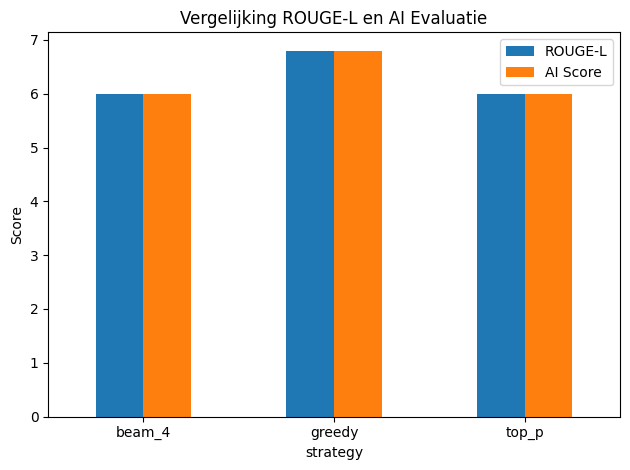

In [ ]:
# Gemiddelde AI scores
ai_scores = (
    rlaif_df.groupby("strategy")["score"]
    .mean()
)

# ROUGE scores
rouge_scores = pd.Series(strategy_scores)

# Gezamenlijke dataframe
comparison_df = pd.DataFrame({
    "ROUGE-L": rouge_scores,
    "AI Score": ai_scores
})

print(comparison_df)

comparison_df.plot(kind="bar")

plt.title("Vergelijking ROUGE-L en AI Evaluatie")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Analyse van de resultaten

In bovenstaande tabel en visualisatie zijn de verschillende samplingstrategieën vergeleken op basis van:
- ROUGE-L scores
- AI evaluatiescores uit RLAIF

### Observaties

- **Greedy decoding** behaalde de hoogste score.
  - Deze strategie genereerde de meest consistente en stabiele titels.
  - De titels sloten vaak goed aan op de originele referentietitels.

- **Beam search** behaalde een iets lagere score.
  - Hoewel beam search vaak grammaticaal sterke titels produceerde, waren sommige titels langer of minder direct vergelijkbaar met de referentietitels.

- **Top-p sampling** scoorde vergelijkbaar met beam search.
  - Deze strategie genereerde creatievere output, maar was minder consistent en soms minder relevant.

### Opvallend resultaat

De ROUGE-L scores en AI evaluatiescores liggen dicht bij elkaar. Dit suggereert dat titels met hogere woordoverlap vaak ook kwalitatief beter werden beoordeeld door het evaluator-model.

### Reflectie

Hoewel greedy decoding de hoogste scores behaalde binnen deze dataset, betekent dit niet dat greedy decoding altijd de beste strategie is. Bij grotere datasets of creatievere teksttaken kunnen beam search of sampling-methodes betere resultaten geven.

Daarnaast blijft ROUGE beperkt tot tekstuele overlap. Daarom is aanvullend gebruikgemaakt van AI feedback via RLAIF om ook inhoudelijke kwaliteit en academische stijl mee te nemen in de evaluatie.

## Conclusie

Binnen dit project is een volledige NLP pipeline ontwikkeld voor titelgeneratie op basis van HBO Kennisbank publicaties. Hiervoor is eerst met prompt engineering een scraping pipeline gebouwd, waarna een FLAN-T5 model is gefinetuned voor titelgeneratie.

Verschillende samplingstrategieën zijn geëvalueerd met zowel ROUGE als AI feedback via RLAIF. Beam search leverde hierbij de meest consistente academische titels op.